In [ ]:
# Paso 1: Cargar dataset
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# Cargar datos
df = sns.load_dataset("penguins")
print(df.head())

# Paso 2: Eliminar valores nulos
df = df.dropna(subset=["species", "bill_length_mm"])

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


In [ ]:
# Paso 3: Análisis exploratorio
print(df.describe())
print(df['species'].value_counts())
print(df['island'].value_counts())
print(df['sex'].value_counts())

       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      342.000000     342.000000         342.000000   342.000000
mean        43.921930      17.151170         200.915205  4201.754386
std          5.459584       1.974793          14.061714   801.954536
min         32.100000      13.100000         172.000000  2700.000000
25%         39.225000      15.600000         190.000000  3550.000000
50%         44.450000      17.300000         197.000000  4050.000000
75%         48.500000      18.700000         213.000000  4750.000000
max         59.600000      21.500000         231.000000  6300.000000
species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64
island
Biscoe       167
Dream        124
Torgersen     51
Name: count, dtype: int64
sex
Male      168
Female    165
Name: count, dtype: int64


In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.power import TTestIndPower
# Paso 4a: Prueba de hipótesis - Adelie vs Gentoo (bill_length_mm)
adelie = df[df['species'] == 'Adelie']['bill_length_mm']
gentoo = df[df['species'] == 'Gentoo']['bill_length_mm']
t_stat_a, p_val_a = stats.ttest_ind(adelie, gentoo, equal_var=False)
print("\nPrueba t entre Adelie y Gentoo (dos colas):")
print("t =", t_stat_a, "p =", p_val_a)


Prueba t entre Adelie y Gentoo (dos colas):
t = -24.725051896885468 p = 3.0871307320284664e-68


In [ ]:
# Paso 4b: Hipótesis direccional Adelie < Gentoo
t_stat_b, p_val_b = stats.ttest_ind(adelie, gentoo, equal_var=False, alternative='less')
print("\nHipótesis direccional (Adelie < Gentoo):")
print("t =", t_stat_b, "p =", p_val_b)


Hipótesis direccional (Adelie < Gentoo):
t = -24.725051896885468 p = 1.5435653660142332e-68


In [ ]:
# Paso 4c: Comparar body_mass_g entre Chinstrap y Gentoo
chinstrap = df[df['species'] == 'Chinstrap']['body_mass_g']
gentoo_weight = df[df['species'] == 'Gentoo']['body_mass_g']
t_stat_c, p_val_c = stats.ttest_ind(chinstrap, gentoo_weight, equal_var=False)
print("\nPrueba t entre Chinstrap y Gentoo (peso corporal):")
print("t =", t_stat_c, "p =", p_val_c)


Prueba t entre Chinstrap y Gentoo (peso corporal):
t = -20.627794010997135 p = 3.413963146026216e-48


In [ ]:
# Paso 4d: ANOVA una vía para island
anova_model = smf.ols('bill_length_mm ~ C(island)', data=df).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)
print("\nANOVA - influencia de la isla en bill_length_mm:")
print(anova_table)


ANOVA - influencia de la isla en bill_length_mm:
                sum_sq     df          F        PR(>F)
C(island)  1565.598964    2.0  30.861864  4.859722e-13
Residual   8598.606562  339.0        NaN           NaN


  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1   group2  meandiff p-adj   lower   upper  reject
-------------------------------------------------------
Biscoe     Dream  -1.0897 0.1629 -2.4952  0.3157  False
Biscoe Torgersen  -6.3065    0.0 -8.2033 -4.4097   True
 Dream Torgersen  -5.2168    0.0  -7.189 -3.2445   True
-------------------------------------------------------


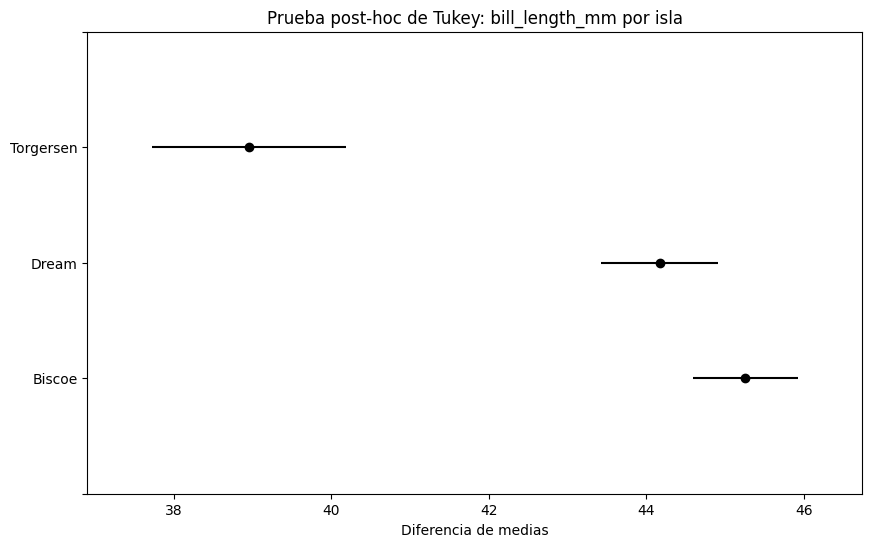

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Aplicar la prueba de Tukey HSD
tukey_result = pairwise_tukeyhsd(endog=df['bill_length_mm'],
                                 groups=df['island'],
                                 alpha=0.05)

# Mostrar resultados
print(tukey_result)

# Gráfico opcional
tukey_result.plot_simultaneous()
plt.title("Prueba post-hoc de Tukey: bill_length_mm por isla")
plt.xlabel("Diferencia de medias")
plt.show()

In [ ]:
from scipy.stats import t

# Obtener grados de libertad residuales y MS_error de la tabla ANOVA
df_residual = anova_table.loc['Residual', 'df']
ms_error = anova_table.loc['Residual', 'sum_sq'] / df_residual

# Tamaños de muestra por grupo
n_group = df.groupby("island").size()
n_mean = (2 * n_group.min() * n_group.max()) / (n_group.min() + n_group.max())  # media armónica

# Valor crítico t (dos colas)
alpha = 0.05
t_crit = t.ppf(1 - alpha / 2, df_residual)

# Calcular la DMS
DMS = t_crit * np.sqrt(2 * ms_error / n_mean)
print(f"Diferencia Mínima Significativa (DMS): {DMS:.4f}")

Diferencia Mínima Significativa (DMS): 1.5849


In [ ]:
from itertools import combinations

# Paso 1: Calcular la media del largo del pico por isla
media_islas = df.groupby('island')['bill_length_mm'].mean()

# Paso 2: Comparar todos los pares de islas
pares = list(combinations(media_islas.index, 2))

# Paso 3: Calcular diferencias y determinar si son significativas
print("Comparación de pares de islas con DMS = {:.4f}\n".format(DMS))
for isla1, isla2 in pares:
    media1 = media_islas[isla1]
    media2 = media_islas[isla2]
    dif = abs(media1 - media2)
    significativo = "✅ Significativa" if dif > DMS else "❌ No significativa"
    print(f"{isla1} vs {isla2}: |{media1:.2f} - {media2:.2f}| = {dif:.4f} → {significativo}")

Comparación de pares de islas con DMS = 1.5849

Biscoe vs Dream: |45.26 - 44.17| = 1.0897 → ❌ No significativa
Biscoe vs Torgersen: |45.26 - 38.95| = 6.3065 → ✅ Significativa
Dream vs Torgersen: |44.17 - 38.95| = 5.2168 → ✅ Significativa


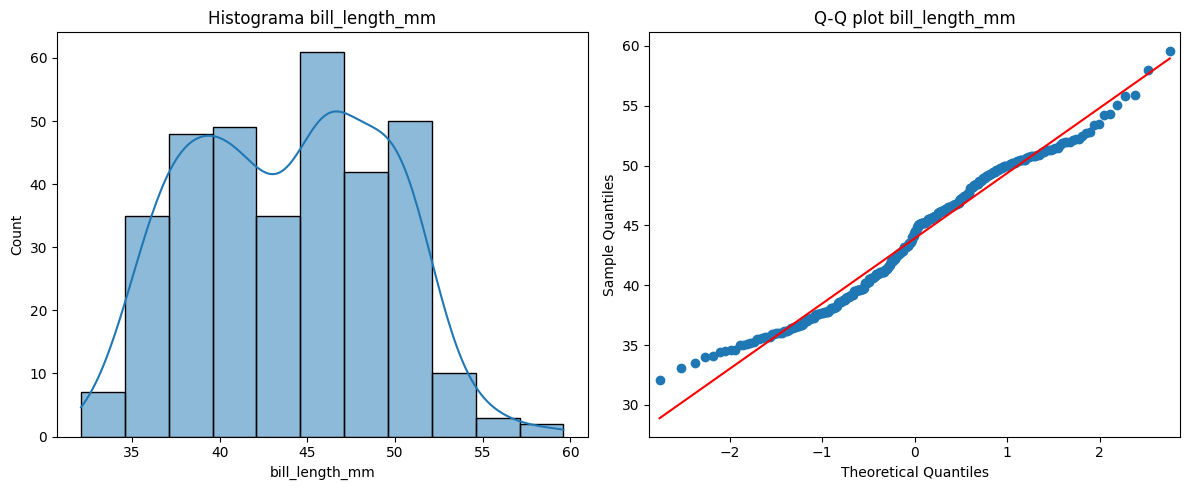

In [ ]:
# Paso 4e: Normalidad - Histograma y Q-Q plot
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['bill_length_mm'], kde=True)
plt.title('Histograma bill_length_mm')
plt.subplot(1,2,2)
sm.qqplot(df['bill_length_mm'], line='s', ax=plt.gca())
plt.title('Q-Q plot bill_length_mm')
plt.tight_layout()
plt.show()

In [ ]:
# Paso 4f: Prueba de igualdad de varianzas (Levene)
levene_stat, levene_p = stats.levene(adelie, gentoo)
print("\nPrueba de Levene - igualdad de varianzas entre Adelie y Gentoo:")
print("W =", levene_stat, "p =", levene_p)


Prueba de Levene - igualdad de varianzas entre Adelie y Gentoo:
W = 1.6441301153817782 p = 0.2008514833712486


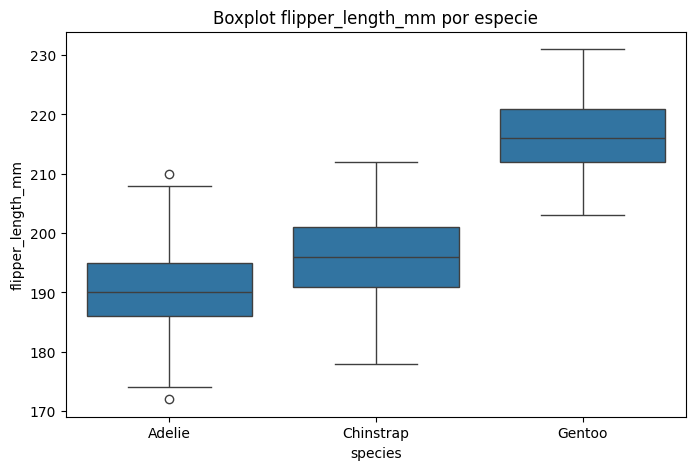

In [ ]:
# Paso 4g: Boxplot flipper_length_mm por especie
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='species', y='flipper_length_mm')
plt.title('Boxplot flipper_length_mm por especie')
plt.show()

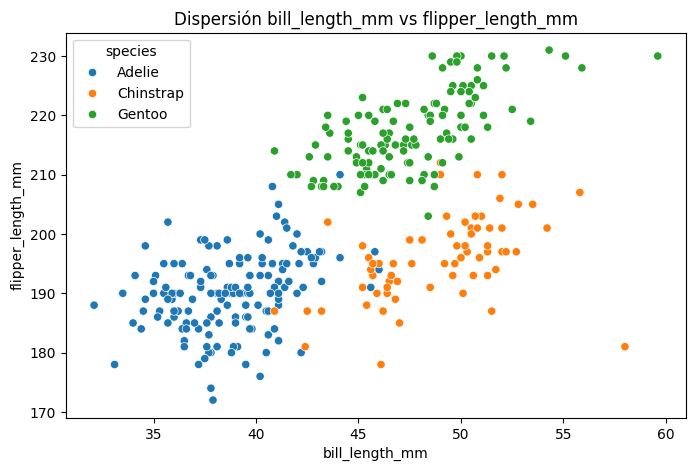

In [ ]:
# Paso 4h: Gráfico de dispersión bill_length_mm vs flipper_length_mm
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='bill_length_mm', y='flipper_length_mm', hue='species')
plt.title('Dispersión bill_length_mm vs flipper_length_mm')
plt.show()


In [ ]:
# Paso 4i: Comparar proporción machos vs hembras entre Adelie y Gentoo
sex_counts = df[df['species'].isin(['Adelie', 'Gentoo'])].groupby(['species', 'sex']).size().unstack()
count = np.array([sex_counts.loc['Adelie', 'Male'], sex_counts.loc['Gentoo', 'Male']])
nobs = np.array([sex_counts.loc['Adelie'].sum(), sex_counts.loc['Gentoo'].sum()])
z_stat, p_val_i = proportions_ztest(count, nobs)
print("\nPrueba z para comparación de proporciones (machos Adelie vs Gentoo):")
print("z =", z_stat, "p =", p_val_i)


Prueba z para comparación de proporciones (machos Adelie vs Gentoo):
z = -0.20414046336370958 p = 0.8382437348653554


In [ ]:
# Paso 4j: Potencia de la prueba para diferencia de medias
std_dev = df[df['species'].isin(['Adelie', 'Gentoo'])]['bill_length_mm'].std()
effect_size = 2 / std_dev  # diferencia verdadera entre medias = 2 mm
analysis = TTestIndPower()
power = analysis.power(effect_size=effect_size, nobs1=40, alpha=0.05, ratio=1.0, alternative='two-sided')
print("\nPotencia de la prueba (diferencia real = 2 mm, n=40):")
print("Potencia =", round(power, 4))


Potencia de la prueba (diferencia real = 2 mm, n=40):
Potencia = 0.3977
